In [1]:
from imports_for_ML import *
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
img_dir = r'train'
images = os.listdir(img_dir)
images[:3]

['dog.8011.jpg', 'cat.5077.jpg', 'dog.7322.jpg']

In [4]:
full_images = [os.path.join(img_dir, img) for img in images]

In [5]:
full_images[:3]

['/Users/jakubwojciechowski/Library/CloudStorage/OneDrive-AkademiaLeonaKozminskiego/Introduction to Python and Machine Learning/Project/train/dog.8011.jpg',
 '/Users/jakubwojciechowski/Library/CloudStorage/OneDrive-AkademiaLeonaKozminskiego/Introduction to Python and Machine Learning/Project/train/cat.5077.jpg',
 '/Users/jakubwojciechowski/Library/CloudStorage/OneDrive-AkademiaLeonaKozminskiego/Introduction to Python and Machine Learning/Project/train/dog.7322.jpg']

In [6]:
from imports_for_ML import load_images

X, y = load_images(img_dir, n_images=10000, resize=(96, 96))

**************************************************
**************************************************
**************************************************
**************************************************
**************************************************
**************************************************
**************************************************
**************************************************
**************************************************
**************************************************


In [7]:
X = X.astype("float32") / 255.0

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=23, stratify=y)

In [9]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

In [10]:
model = Sequential()
model.add(Input(shape=(96, 96, 3)))

model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(1, activation="sigmoid"))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])

stop_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499,873 (9.54 MB)

 Trainable params: 2,499,425 (9.53 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
history = model.fit(  X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, callbacks=[stop_early, reduce_lr])

Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 71s 308ms/step - accuracy: 0.5731 - loss: 0.8932 - val_accuracy: 0.4544 - val_loss: 1.0437 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 69s 306ms/step - accuracy: 0.6392 - loss: 0.6324 - val_accuracy: 0.5317 - val_loss: 1.2562 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 69s 309ms/step - accuracy: 0.6792 - loss: 0.5947 - val_accuracy: 0.4900 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 70s 312ms/step - accuracy: 0.7188 - loss: 0.5533 - val_accuracy: 0.7089 - val_loss: 0.6138 - learning_rate: 0.0010
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 71s 317ms/step - accuracy: 0.7343 - loss: 0.5624 - val_accuracy: 0.5439 - val_loss: 0.8311 - learning_rate: 0.0010
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 72s 321ms/step - accuracy: 0.7685 - loss: 0.4938 - val_accuracy: 0.6933 - val_loss: 0.6206 - learning_rate: 0.0010
Epoch 7/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 71s 318ms/step - accuracy: 0.8

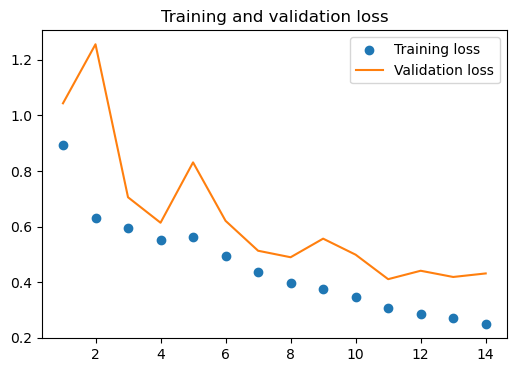

In [13]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(6, 4))

plt.scatter(epochs, train_loss, label="Training loss", color="C0")

plt.plot(epochs, val_loss, label="Validation loss", color="C1")

plt.title("Training and validation loss")
plt.legend()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.3932724595069885
Test accuracy: 0.8309999704360962


In [15]:
predicted_probabilities = model.predict(X_test)
predicted_probabilities[:5]

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


array([[0.1510663 ],
       [0.9966409 ],
       [0.04866696],
       [0.12068112],
       [0.2344615 ]], dtype=float32)

In [16]:
predicted_labels = (predicted_probabilities > 0.5).astype(int).flatten()
predicted_labels[:10]

array([0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

In [17]:
correct = (predicted_labels.flatten() == y_test.flatten())

print("Correct:", correct.sum())
print("Incorrect:", (~correct).sum())

Correct: 831
Incorrect: 169


In [18]:
correct_idx = np.where(correct)[0][:6]
wrong_idx = np.where(~correct)[0][:6]

print("Correct indexes:", correct_idx)
print("Incorrect indexes:", wrong_idx)

Correct indexes: [0 1 2 3 5 6]
Incorrect indexes: [ 4 14 16 18 22 29]


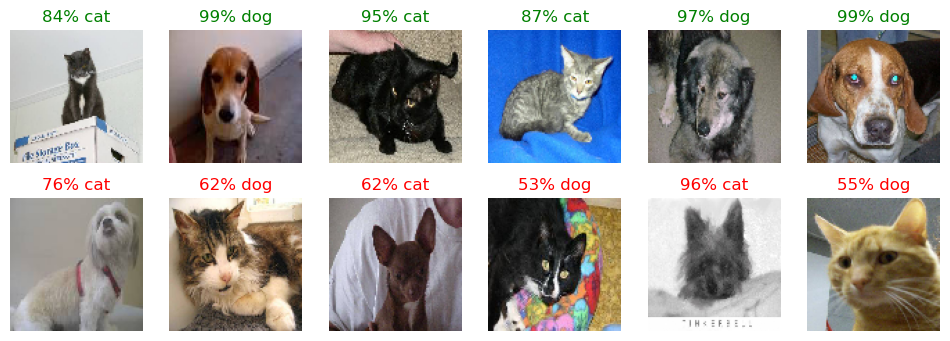

In [19]:
plt.figure(figsize=(12, 4))

for i, idx in enumerate(correct_idx):
    plt.subplot(2, 6, i+1)
    plt.imshow(X_test[idx])
    probability = float(predicted_probabilities[idx][0])
    predicted_label = int(predicted_labels[idx])
    label = "dog" if predicted_label == 1 else "cat"
    score = probability if predicted_label == 1 else (1.0 - probability)
    plt.title(str(int(score*100)) + "% " + label, color="green")
    plt.axis("off")

for i, idx in enumerate(wrong_idx):
    plt.subplot(2, 6, i+7)
    plt.imshow(X_test[idx])
    probability = float(predicted_probabilities[idx][0])
    predicted_label = int(predicted_labels[idx])
    label = "dog" if predicted_label == 1 else "cat"
    score = probability if predicted_label == 1 else (1.0 - probability)
    plt.title(str(int(score*100)) + "% " + label, color="red")
    plt.axis("off")

plt.show()

In [20]:
def predict_one_image(path):
    img = load_img(path, target_size=(96, 96))
    arr = img_to_array(img)
    arr = arr / 255.0
    arr = np.expand_dims(arr, axis=0)

    probability = float(model.predict(arr)[0][0])
    label = "dog" if probability > 0.5 else "cat"

    plt.imshow(img)
    plt.axis("off")
    print("File:", path)
    print("Probability of dog:", probability)
    print("Result:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
File: /Users/jakubwojciechowski/Library/CloudStorage/OneDrive-AkademiaLeonaKozminskiego/Introduction to Python and Machine Learning/Project/My photos/cat.jpeg
Probability of dog: 0.011392198503017426
Result: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
File: /Users/jakubwojciechowski/Library/CloudStorage/OneDrive-AkademiaLeonaKozminskiego/Introduction to Python and Machine Learning/Project/My photos/dog.jpg
Probability of dog: 0.4475470185279846
Result: cat


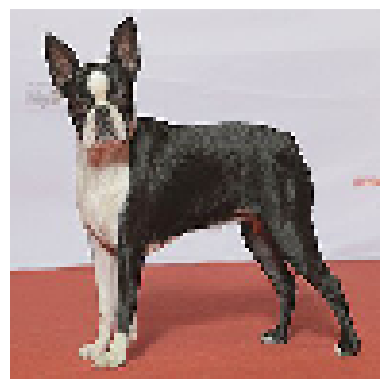

In [ ]:
predict_one_image('My photos/cat.jpeg')
predict_one_image('My photos/dog.jpg')

In [22]:
model.save("JAKUB_WOJCIECHOWSKI_49872_MODEL.keras")